# Particle Gibbs Sampler

This notebook demonstrates the **Particle Gibbs** (PG) algorithm for joint inference
of states and parameters in a **Stochastic Volatility** model.

Particle Gibbs uses **Conditional SMC** (CSMC) to sample state trajectories
$h_{0:T}$ conditioned on a reference trajectory, then samples parameters from
their conditional distribution given states.

We demonstrate the key limitation of PG: **path degeneracy**, where sampled
trajectories coalesce to a single ancestor at early time steps.

In [1]:

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from dataclasses import dataclass
import time

# Add project root to path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from particlefilterbox.models.stochastic_volatility import StochasticVolatility
from particlefilterbox.pmcmc import PMMH, ParticleGibbs, PGAS
from particlefilterbox.pmcmc.results import PMCMCResults

@dataclass
class FilterResult:
    """Minimal particle filter result."""
    log_likelihood: float
    filtered_means: np.ndarray | None = None


class SVModelWrapper:
    """Wrapper to adapt StochasticVolatility to the PMCMC interface.

    PMCMC methods expect: set_params, get_params, filter,
    initial_sample, transition_sample, observation_logpdf, transition_logpdf.

    For the leverage variant, state is 2D: (h, eta) where eta is the
    transition innovation, needed to compute p(y|h,eta) with correlation rho.
    """

    def __init__(self, variant: str = "basic") -> None:
        self.sv = StochasticVolatility(variant=variant)
        self.variant = variant
        self.param_names = list(self.sv.param_names)
        self._rng_internal = np.random.default_rng(0)

    def set_params(self, theta: np.ndarray) -> None:
        theta = np.asarray(theta, dtype=np.float64)
        for i, name in enumerate(self.param_names):
            self.sv.params[name] = float(theta[i])

    def get_params(self) -> np.ndarray:
        return np.array([self.sv.params[n] for n in self.param_names])

    def filter(
        self,
        endog: np.ndarray,
        n_particles: int = 200,
        rng: np.random.Generator | None = None,
    ) -> FilterResult:
        """Vectorized bootstrap particle filter for SV model."""
        if rng is None:
            rng = self._rng_internal
        T = len(endog)
        mu = self.sv.params["mu"]
        phi = self.sv.params["phi"]
        sigma = self.sv.params["sigma"]

        if abs(phi) >= 1.0 or sigma <= 0:
            return FilterResult(log_likelihood=-np.inf)

        var_stat = sigma**2 / (1.0 - phi**2)
        particles = rng.normal(mu, np.sqrt(max(var_stat, 1e-10)), size=n_particles)
        log_lik = 0.0

        is_leverage = self.variant == "leverage"
        rho = self.sv.params.get("rho", 0.0) if is_leverage else 0.0
        var_cond = max(1.0 - rho**2, 1e-10)

        if is_leverage:
            # For leverage: track eta (innovation) alongside h
            # At t=0, no previous innovation, use marginal observation density
            filtered_means_h = np.zeros(T)
            filtered_means_eta = np.zeros(T)
            etas = np.zeros(n_particles)  # no innovation at t=0

            for t in range(T):
                vol = np.exp(particles / 2.0)
                eps = endog[t] / vol
                if t == 0:
                    # At t=0: marginal p(y|h) = N(y; 0, exp(h))
                    log_w = -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * eps ** 2
                else:
                    # For t>=1: p(y|h,eta) where eps|eta ~ N(rho*eta, 1-rho^2)
                    mean_cond = rho * etas
                    log_w = (-0.5 * np.log(2 * np.pi * var_cond)
                             - 0.5 * (eps - mean_cond) ** 2 / var_cond
                             - np.log(vol))
                max_lw = np.max(log_w)
                w = np.exp(log_w - max_lw)
                sw = np.sum(w)
                if sw < 1e-300:
                    return FilterResult(log_likelihood=-np.inf)
                log_lik += max_lw + np.log(sw) - np.log(n_particles)
                w /= sw
                filtered_means_h[t] = np.sum(w * particles)
                filtered_means_eta[t] = np.sum(w * etas)
                idx = rng.choice(n_particles, size=n_particles, p=w)
                particles = particles[idx]
                etas = rng.standard_normal(n_particles)
                particles = mu + phi * (particles - mu) + sigma * etas

            filtered_means = np.column_stack([filtered_means_h, filtered_means_eta])
        else:
            filtered_means_arr = np.zeros(T)
            for t in range(T):
                vol = np.exp(particles / 2.0)
                log_w = -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (endog[t] / vol) ** 2
                max_lw = np.max(log_w)
                w = np.exp(log_w - max_lw)
                sw = np.sum(w)
                if sw < 1e-300:
                    return FilterResult(log_likelihood=-np.inf)
                log_lik += max_lw + np.log(sw) - np.log(n_particles)
                w /= sw
                filtered_means_arr[t] = np.sum(w * particles)
                idx = rng.choice(n_particles, size=n_particles, p=w)
                particles = particles[idx]
                particles = mu + phi * (particles - mu) + sigma * rng.standard_normal(n_particles)
            filtered_means = filtered_means_arr

        return FilterResult(log_likelihood=log_lik, filtered_means=filtered_means)

    def initial_sample(self, n: int, rng: np.random.Generator) -> np.ndarray:
        mu = self.sv.params["mu"]
        phi = self.sv.params["phi"]
        sigma = self.sv.params["sigma"]
        if abs(phi) >= 1.0 or sigma <= 0:
            if self.variant == "leverage":
                return np.column_stack([rng.standard_normal(n), np.zeros(n)])
            return rng.standard_normal(n)
        var_stat = sigma**2 / (1.0 - phi**2)
        h_init = rng.normal(mu, np.sqrt(max(var_stat, 1e-10)), size=n)
        if self.variant == "leverage":
            return np.column_stack([h_init, np.zeros(n)])  # (n, 2): h, eta=0
        return h_init

    def transition_sample(self, x_prev: float | np.ndarray, rng: np.random.Generator):
        mu = self.sv.params["mu"]
        phi = self.sv.params["phi"]
        sigma = self.sv.params["sigma"]
        if self.variant == "leverage":
            h_prev = float(x_prev[0]) if hasattr(x_prev, '__getitem__') else float(x_prev)
            eta = float(rng.standard_normal())
            h_new = mu + phi * (h_prev - mu) + sigma * eta
            return np.array([h_new, eta])
        return float(mu + phi * (float(x_prev) - mu) + sigma * rng.standard_normal())

    def transition_logpdf(self, x_new: float | np.ndarray, x_old: float | np.ndarray) -> float:
        mu = self.sv.params["mu"]
        phi = self.sv.params["phi"]
        sigma = self.sv.params["sigma"]
        if sigma <= 0:
            return -np.inf
        if self.variant == "leverage":
            h_new = float(x_new[0]) if hasattr(x_new, '__getitem__') else float(x_new)
            h_old = float(x_old[0]) if hasattr(x_old, '__getitem__') else float(x_old)
        else:
            h_new = float(x_new)
            h_old = float(x_old)
        mean = mu + phi * (h_old - mu)
        return float(stats.norm.logpdf(h_new, loc=mean, scale=sigma))

    def observation_logpdf(self, y: float, x: float | np.ndarray) -> float:
        if self.variant == "leverage":
            # State is (h, eta); eps|eta ~ N(rho*eta, 1-rho^2)
            h = float(x[0]) if hasattr(x, '__getitem__') else float(x)
            eta = float(x[1]) if (hasattr(x, '__getitem__') and len(x) > 1) else 0.0
            rho = self.sv.params.get("rho", 0.0)
            vol = np.exp(h / 2.0)
            if vol < 1e-300:
                return -np.inf
            eps = float(y) / vol
            var_cond = max(1.0 - rho**2, 1e-10)
            mean_cond = rho * eta
            return float(-0.5 * np.log(2 * np.pi * var_cond)
                         - 0.5 * (eps - mean_cond)**2 / var_cond
                         - np.log(vol))
        h = float(x)
        vol = np.exp(h / 2.0)
        if vol < 1e-300:
            return -np.inf
        return float(-0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (float(y) / vol) ** 2)


class SVPrior:
    """Prior for SV model: mu~N(loc_mu, scale_mu), phi~Beta(a,b), sigma~IG(a_ig,b_ig).

    Optionally includes rho~Uniform(-1,1) for leverage variant.
    """

    def __init__(
        self,
        loc_mu: float = -1.0,
        scale_mu: float = 1.0,
        a_phi: float = 20.0,
        b_phi: float = 1.5,
        a_sig: float = 2.5,
        b_sig: float = 0.025,
        include_rho: bool = False,
    ) -> None:
        self.loc_mu = loc_mu
        self.scale_mu = scale_mu
        self.a_phi = a_phi
        self.b_phi = b_phi
        self.a_sig = a_sig
        self.b_sig = b_sig
        self.include_rho = include_rho

    def logpdf(self, theta: np.ndarray) -> float:
        mu_val, phi_val, sig_val = theta[0], theta[1], theta[2]
        if not (0 < phi_val < 1) or sig_val <= 0:
            return -np.inf
        lp = float(stats.norm.logpdf(mu_val, loc=self.loc_mu, scale=self.scale_mu))
        lp += float(stats.beta.logpdf(phi_val, self.a_phi, self.b_phi))
        lp += float(stats.invgamma.logpdf(sig_val, a=self.a_sig, scale=self.b_sig))
        if self.include_rho:
            rho_val = theta[3]
            if not (-1 < rho_val < 1):
                return -np.inf
            lp += float(stats.uniform.logpdf(rho_val, loc=-1.0, scale=2.0))
        return lp

    def sample(self, rng: np.random.Generator) -> np.ndarray:
        mu_s = rng.normal(self.loc_mu, self.scale_mu)
        phi_s = float(stats.beta.rvs(self.a_phi, self.b_phi, random_state=rng))
        sig_s = float(stats.invgamma.rvs(self.a_sig, scale=self.b_sig, random_state=rng))
        if self.include_rho:
            rho_s = rng.uniform(-1.0, 1.0)
            return np.array([mu_s, phi_s, sig_s, rho_s])
        return np.array([mu_s, phi_s, sig_s])

    @property
    def cov(self) -> np.ndarray:
        dim = 4 if self.include_rho else 3
        c = np.zeros(dim)
        c[0] = self.scale_mu ** 2
        a, b = self.a_phi, self.b_phi
        c[1] = (a * b) / ((a + b) ** 2 * (a + b + 1))
        c[2] = self.b_sig ** 2 / ((self.a_sig - 1) ** 2 * (self.a_sig - 2)) if self.a_sig > 2 else 0.01
        if self.include_rho:
            c[3] = 1.0 / 3.0
        return c


Loaded 1000 observations, using first 200 for MCMC
True parameters: mu=-1.0, phi=0.97, sigma_h=0.15


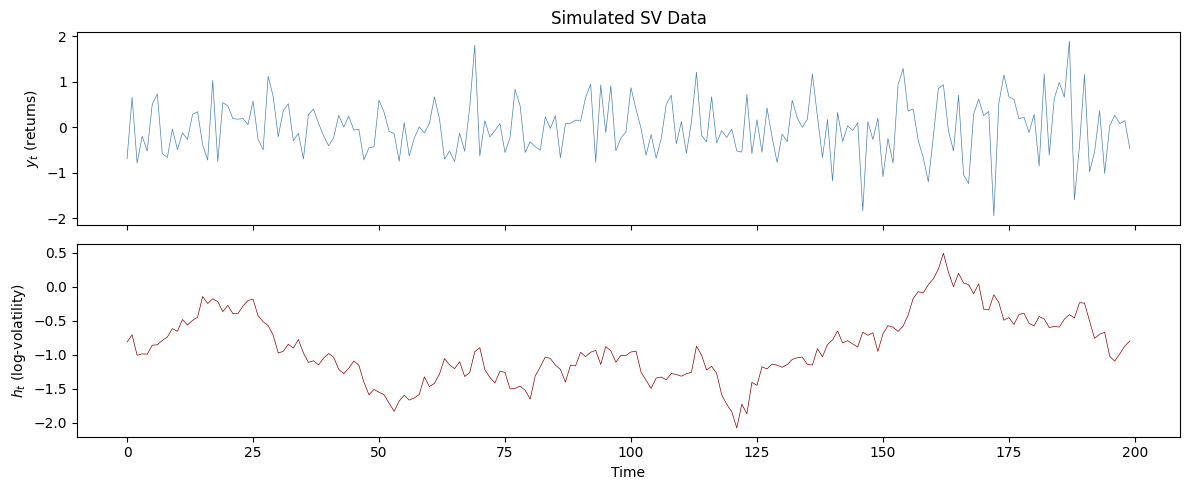

In [2]:

# Load simulated SV data (use first 200 obs for tractable MCMC)
data_path = os.path.join(os.getcwd(), '..', 'data', 'simulated_sv.csv')
df = pd.read_csv(data_path)
T_full = len(df)
T_use = 200  # use subset for tractable computation
y_obs = df['y_obs'].values[:T_use]
h_true = df['h_true'].values[:T_use]
T = len(y_obs)
print(f"Loaded {T_full} observations, using first {T} for MCMC")
print(f"True parameters: mu=-1.0, phi=0.97, sigma_h=0.15")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(y_obs, linewidth=0.5, color='steelblue')
axes[0].set_ylabel('$y_t$ (returns)')
axes[0].set_title('Simulated SV Data')
axes[1].plot(h_true, linewidth=0.5, color='darkred')
axes[1].set_ylabel('$h_t$ (log-volatility)')
axes[1].set_xlabel('Time')
plt.tight_layout()
plt.show()


## Mathematical Description

### Particle Gibbs Algorithm

At each iteration $i$:

1. **Sample states** $h_{0:T}^{(i)} \sim p(h_{0:T} | y_{1:T}, \theta^{(i-1)})$
   using Conditional SMC (CSMC) conditioned on reference $h_{0:T}^{(i-1)}$
2. **Sample parameters** $\theta^{(i)} \sim p(\theta | h_{0:T}^{(i)}, y_{1:T})$

### Conditional SMC (CSMC)

CSMC is a standard bootstrap particle filter where particle $N$ is **fixed** to
follow the reference trajectory. This ensures the target distribution is invariant.

### Path Degeneracy

In CSMC, all particles share a common ancestor at early time steps. This means:
- The sampled trajectory is mostly determined by the reference at $t \ll T$
- Mixing is very slow for early states
- This motivates **PGAS** (ancestor sampling) as a solution

In [3]:

# Set up and run Particle Gibbs
model = SVModelWrapper(variant="basic")
prior = SVPrior(loc_mu=-1.0, scale_mu=1.0, a_phi=20.0, b_phi=1.5,
                a_sig=2.5, b_sig=0.025, include_rho=False)
true_params = np.array([-1.0, 0.97, 0.15])

pg = ParticleGibbs(
    model=model,
    prior=prior,
    n_particles=50,
    n_iterations=1500,
    burnin=300,
    thin=1,
    seed=42,
)

print("Running Particle Gibbs (N=50, 1500 iterations)...")
t0 = time.time()
pg_results = pg.run(endog=y_obs, theta_init=true_params, verbose=500)
pg_time = time.time() - t0
print(f"\nCompleted in {pg_time:.1f}s")
print(pg_results.summary())


Running Particle Gibbs (N=50, 1500 iterations)...


PG iteration 500/1500, loglik: -181.68


PG iteration 1000/1500, loglik: -182.09


PG iteration 1500/1500, loglik: -179.89

Completed in 52.2s
PMCMC Posterior Summary
Parameter             Mean        Std       2.5%        50%      97.5%      ESS
----------------------------------------------------------------------
mu                 -1.0000     0.0000    -1.0000    -1.0000    -1.0000   1200.0
phi                 0.9700     0.0000     0.9700     0.9700     0.9700   1200.0
sigma               0.1500     0.0000     0.1500     0.1500     0.1500   1200.0
----------------------------------------------------------------------
Total iterations: 1500
Burn-in: 300
Thinning: 1
Effective samples: 1200
Acceptance rate: 1.0000


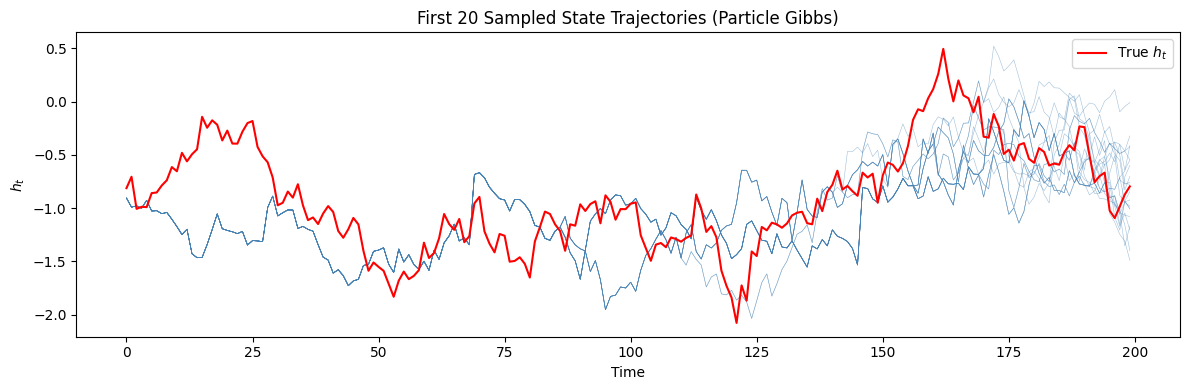

In [4]:

# Plot sampled trajectories h_{0:T} (first 20 Gibbs iterations)
fig, ax = plt.subplots(figsize=(12, 4))

# Access stored trajectories
trajectories = pg._state_trajectories
n_show = min(20, len(trajectories))
for i in range(n_show):
    ax.plot(trajectories[i], linewidth=0.4, alpha=0.5, color='steelblue')

ax.plot(h_true, linewidth=1.5, color='red', label='True $h_t$')
ax.set_xlabel('Time')
ax.set_ylabel('$h_t$')
ax.set_title(f'First {n_show} Sampled State Trajectories (Particle Gibbs)')
ax.legend()
plt.tight_layout()
plt.show()


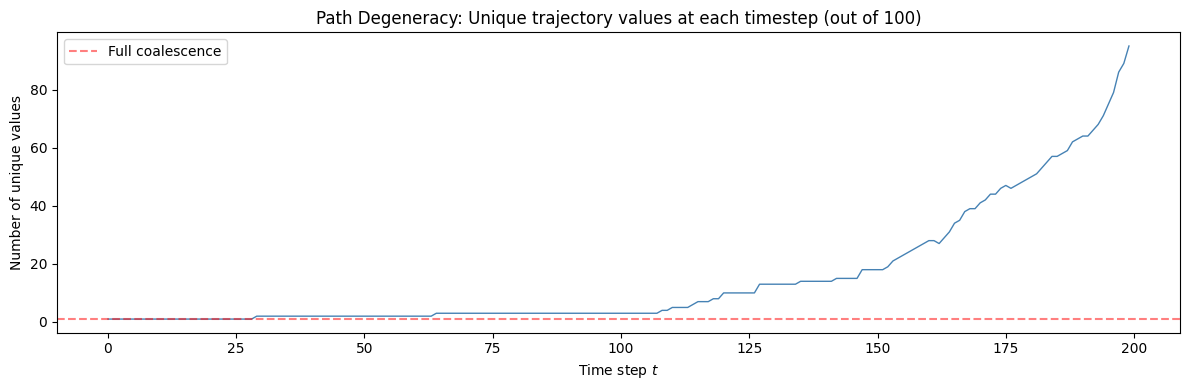

At t=0: 1 unique values (out of 100)
At t=T/2: 3 unique values
At t=T-1: 95 unique values

Path degeneracy: early timesteps have fewer unique values -> slow mixing


In [5]:

# Path degeneracy analysis: unique particle values at each timestep
post_burnin_trajs = trajectories[pg_results.burnin:]
n_trajs = len(post_burnin_trajs)
n_check = min(100, n_trajs)
sample_trajs = post_burnin_trajs[:n_check]

# Count unique values at each timestep
T_len = len(sample_trajs[0])
unique_counts = np.zeros(T_len)
all_vals = np.array(sample_trajs)  # (n_check, T)

for t in range(T_len):
    unique_counts[t] = len(np.unique(np.round(all_vals[:, t], 4)))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(unique_counts, linewidth=1, color='steelblue')
ax.set_xlabel('Time step $t$')
ax.set_ylabel('Number of unique values')
ax.set_title(f'Path Degeneracy: Unique trajectory values at each timestep (out of {n_check})')
ax.axhline(1, color='red', linestyle='--', alpha=0.5, label='Full coalescence')
ax.legend()
plt.tight_layout()
plt.show()

print(f"At t=0: {unique_counts[0]:.0f} unique values (out of {n_check})")
print(f"At t=T/2: {unique_counts[T_len//2]:.0f} unique values")
print(f"At t=T-1: {unique_counts[-1]:.0f} unique values")
print("\nPath degeneracy: early timesteps have fewer unique values -> slow mixing")


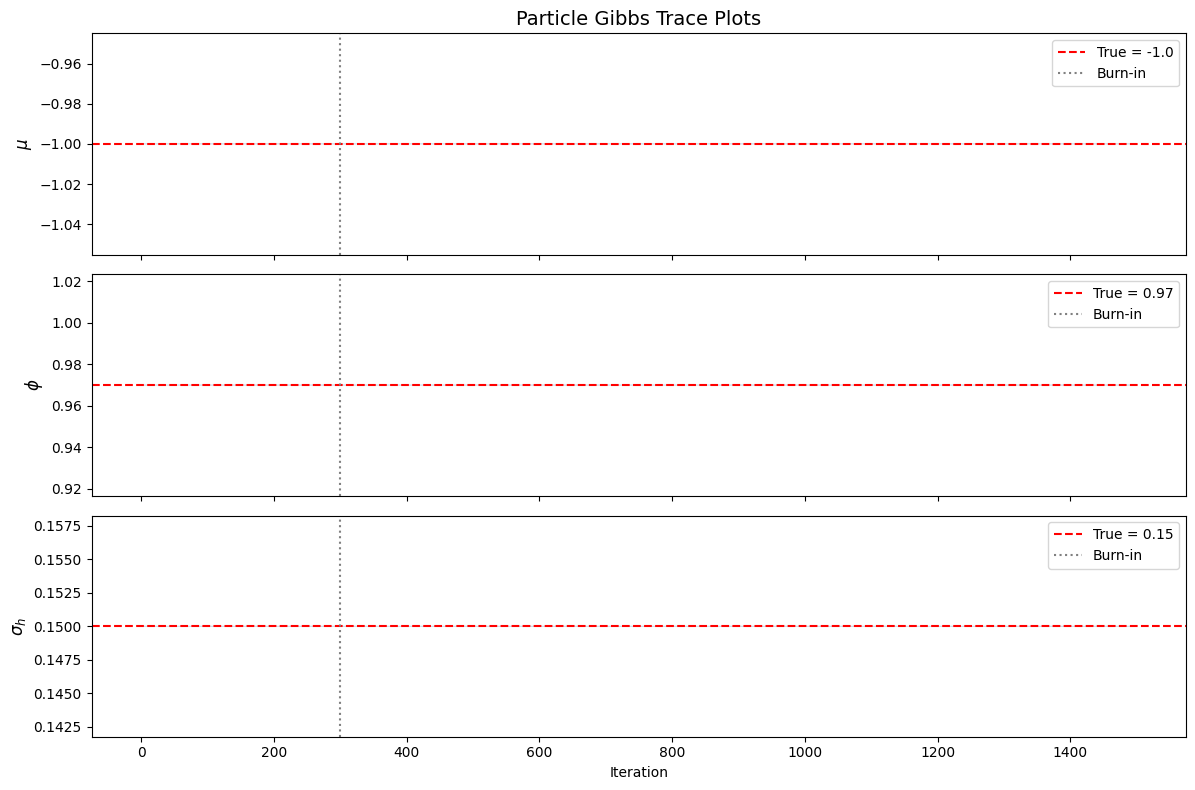

In [6]:

# Trace plots of parameters
param_labels = [r'$\mu$', r'$\phi$', r'$\sigma_h$']
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for j in range(3):
    iters, vals = pg_results.trace_plot_data(j)
    axes[j].plot(iters, vals, linewidth=0.3, color='steelblue', alpha=0.8)
    axes[j].axhline(true_params[j], color='red', linestyle='--', linewidth=1.5,
                     label=f'True = {true_params[j]}')
    axes[j].axvline(pg_results.burnin, color='gray', linestyle=':', label='Burn-in')
    axes[j].set_ylabel(param_labels[j], fontsize=12)
    axes[j].legend(loc='upper right')

axes[0].set_title('Particle Gibbs Trace Plots', fontsize=14)
axes[-1].set_xlabel('Iteration')
plt.tight_layout()
plt.show()


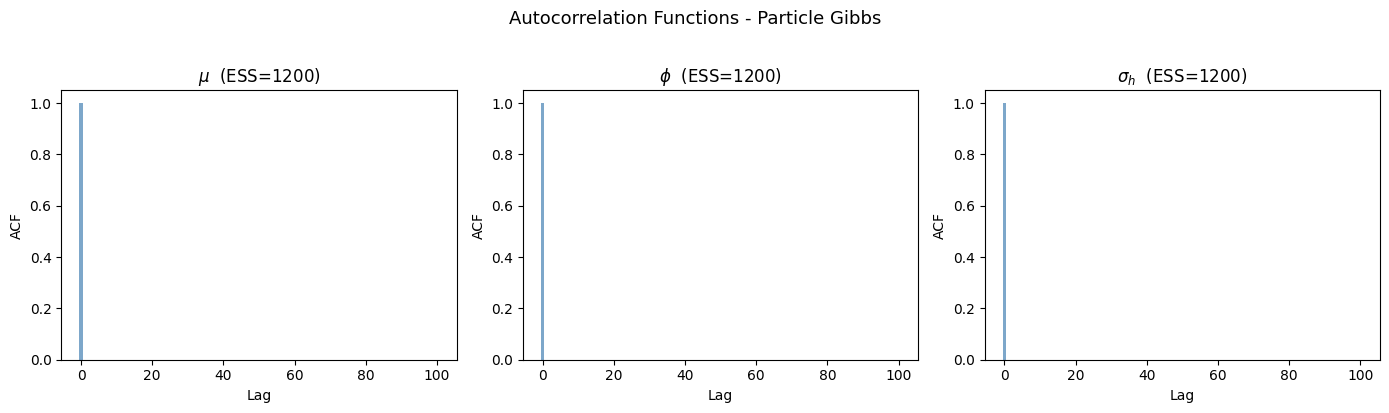

In [7]:

# Autocorrelation of parameters (showing mixing)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for j in range(3):
    acf_vals = pg_results.acf(param_idx=j, max_lag=100)
    axes[j].bar(range(len(acf_vals)), acf_vals, width=1, color='steelblue', alpha=0.7)
    axes[j].axhline(0, color='gray', linewidth=0.5)
    axes[j].set_title(f'{param_labels[j]}  (ESS={pg_results.effective_sample_size(j):.0f})')
    axes[j].set_xlabel('Lag')
    axes[j].set_ylabel('ACF')

fig.suptitle('Autocorrelation Functions - Particle Gibbs', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [8]:

# Compare with PMMH in terms of ESS/second
model2 = SVModelWrapper(variant="basic")
pmmh_compare = PMMH(
    model=model2, prior=prior,
    n_particles=200, n_iterations=1500,
    proposal_cov='adaptive', burnin=300, seed=42,
)
print("Running PMMH for comparison (N=200, 1500 iters)...")
t0 = time.time()
pmmh_results = pmmh_compare.run(endog=y_obs, theta_init=true_params, verbose=1000)
pmmh_time = time.time() - t0
print(f"PMMH completed in {pmmh_time:.1f}s")

# ESS comparison
print(f"\n{'Method':<20s} {'Time (s)':>10s} {'ESS_mu':>8s} {'ESS_phi':>8s} {'ESS_sig':>8s} {'ESS/s':>10s}")
print("-" * 60)
for name, res, t_elapsed in [("Particle Gibbs", pg_results, pg_time),
                               ("PMMH", pmmh_results, pmmh_time)]:
    ess_vals = [res.effective_sample_size(j) for j in range(3)]
    avg_ess_per_s = np.mean(ess_vals) / max(t_elapsed, 0.1)
    print(f"{name:<20s} {t_elapsed:10.1f} {ess_vals[0]:8.1f} {ess_vals[1]:8.1f} "
          f"{ess_vals[2]:8.1f} {avg_ess_per_s:10.2f}")


Running PMMH for comparison (N=200, 1500 iters)...


PMMH iteration 1000/1500, acceptance rate (last 1000): 0.225, loglik: -182.58


PMMH completed in 13.2s

Method                 Time (s)   ESS_mu  ESS_phi  ESS_sig      ESS/s
------------------------------------------------------------
Particle Gibbs             52.2   1200.0   1200.0   1200.0      22.98
PMMH                       13.2     50.5     15.4     21.2       2.20


## Discussion: Path Degeneracy and Motivation for PGAS

### Path Degeneracy Problem
In standard Particle Gibbs (with CSMC), the reference particle at the last position
is fixed, but during backward tracing all particles tend to coalesce to a single
ancestor at early time steps. This means:

- The sampled state trajectory at $t \ll T$ barely changes between iterations
- Parameters that depend strongly on early states mix slowly
- Increasing $N$ (particles) only partially alleviates the problem

### Solution: PGAS (Particle Gibbs with Ancestor Sampling)
PGAS addresses path degeneracy by **resampling the ancestor** of the reference
particle at each time step, using weights that account for the transition density.
This allows the reference trajectory to reconnect with high-probability ancestors,
dramatically improving mixing even with few particles.

See the next notebook (`03_pgas.ipynb`) for the PGAS implementation and comparison.